In [33]:
%matplotlib inline

In [34]:
import glob
from subprocess import run

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [35]:
from transit_time_dependence_plots import (extract_json, extract_json_tts_filter, extract_json_min_tts_filter, extract_json_tts_chi2_filter,plot_single_transit_time_histogram,
                                           prod_id_to_icm_id,extract_channel,extract_fit_params)

from refit_bad_tt_fits import merge_bins_reduceat
from transit_time_fit_functions import gaussian


In [36]:
import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 10})


# colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69']
colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9','#bc80bd','#ccebc5','#ffed6f','#1f78b4','#33a02c','#e31a1c','#a6cee3','#b2df8a','#fb9a99','#fdbf6f','#ff7f00','#cab2d6','#ffff99','#6a3d9a','#b15928','#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666','#1f78b4']


In [37]:
from plot_transit_time_single_per_pmt import (extract_json_site,extract_rse_site,
                                              plot_transit_time_histogram,plot_transit_time_spread_histogram,
                                              plot_rse_histogram)

In [16]:
C_msu = 23.9 #ns
C_desy = 25.5 #ns
upgrade_commissioning_scripts = home+"/research_ua/icecube/software/upgrade_commissioning_scripts/"
geometry_files = sorted(glob.glob(upgrade_commissioning_scripts+"/geometry/string_*geometry*.json"))
mdom_tt_dir = home+"/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/"
plotFolder: str = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/mdom_transit"
run_picks_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_run_picks.json"
refit_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_tt_needing_refit.json"
empty_meas_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_empty_meas.json"

transit_time_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time.json"

In [17]:
transit_times_single_per_pmt_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_single_pick.json"

In [18]:
transit_times_single_per_pmt_msu = extract_json_site(transit_times_single_per_pmt_file,site_str="_M",obj_key="mu",filter_non_zero=False)
transit_times_single_per_pmt_desy = extract_json_site(transit_times_single_per_pmt_file,site_str="_D",obj_key="mu",filter_non_zero=False)
transit_times_spread_single_per_pmt_msu = extract_json_site(transit_times_single_per_pmt_file,site_str="_M",obj_key="c",filter_non_zero=False)
transit_times_spread_single_per_pmt_desy = extract_json_site(transit_times_single_per_pmt_file,site_str="_D",obj_key="c",filter_non_zero=False)


In [23]:
def plot_transit_time_spread_histogram2(transit_times_spread_msu, transit_times_spread_desy, plot_name,bins=200,xlim=[0,1],no_component=None) -> None:
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    if no_component is None:
        ax.hist(transit_times_spread_msu, bins=bins,histtype='step',color=colorsCustom[0],linewidth=1.5 ,label=r'MSU tts', alpha=1)
        ax.hist(transit_times_spread_desy, bins=bins,histtype='step',color=colorsCustom[1],linewidth=1.5 ,label=r'DESY tts', alpha=1)
    ax.hist(transit_times_spread_desy+transit_times_spread_msu, bins=bins,histtype='step',color=colorsCustom[2],linewidth=1.5 ,label=r'Combined tts', alpha=1)
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"time [ns]", fontsize=22)
    ax.set_ylabel(r"count", fontsize=22)
    ax.set_yscale('log')
    if no_component is None:
        ax.text(0.95, 0.95, fr"MSU tts: {np.mean(transit_times_spread_msu):.1f}"+r"$\pm$" + fr" {np.std(transit_times_spread_msu):.1f}  ns", transform=ax.transAxes, ha='right', va='top')
        ax.text(0.95, 0.85, fr"DESY tts: {np.mean(transit_times_spread_desy):.1f}"+r"$\pm$" + fr" {np.std(transit_times_spread_desy):.1f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.text(0.95, 0.75, fr"Combined tts: {np.mean(transit_times_spread_msu+transit_times_spread_desy):.1f}"+r"$\pm$" + fr" {np.std(transit_times_spread_msu+transit_times_spread_desy):.1f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.grid(True,alpha=0.6)
    ax.set_xlim(xlim[0],xlim[1])
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    plt.show()

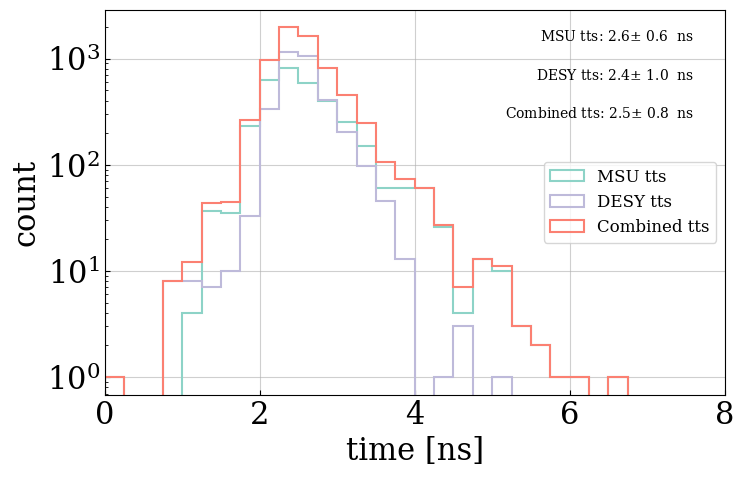

In [26]:
plot_transit_time_spread_histogram2(transit_times_spread_single_per_pmt_msu, transit_times_spread_single_per_pmt_desy,plotFolder+"/transit_time_spread_histogram_final",bins=np.linspace(0,8,33),xlim=[0,8],no_component=None)

In [30]:
def plot_transit_time_histogram2(transit_times_msu, transit_times_desy, plot_name,bins=200,xlim=[45,65],no_component=None) -> None:
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    if no_component is None:
        ax.hist(transit_times_msu, bins=bins,histtype='step',color=colorsCustom[0],linewidth=1.5 ,label=r'MSU tt', alpha=1)
        ax.hist(transit_times_desy, bins=bins,histtype='step',color=colorsCustom[1],linewidth=1.5 ,label=r'DESY tt', alpha=1)
    ax.hist(transit_times_desy+transit_times_msu, bins=bins,histtype='step',color=colorsCustom[2],linewidth=1.5 ,label=r'Combined tt', alpha=1)
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"time [ns]", fontsize=22)
    ax.set_ylabel(r"count", fontsize=22)
    ax.set_yscale('log')
    if no_component is None:
        ax.text(0.95, 0.95, fr"MSU tt: {np.mean(transit_times_msu):.0f}"+r"$\pm$" + fr" {np.std(transit_times_msu):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
        ax.text(0.95, 0.85, fr"DESY tt: {np.mean(transit_times_desy):.0f}"+r"$\pm$" + fr" {np.std(transit_times_desy):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.text(0.95, 0.75, fr"Combined tt: {np.mean(transit_times_msu+transit_times_desy):.0f}"+r"$\pm$" + fr" {np.std(transit_times_msu+transit_times_desy):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.grid(True,alpha=0.6)
    ax.set_xlim(xlim[0],xlim[1])
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    plt.show()

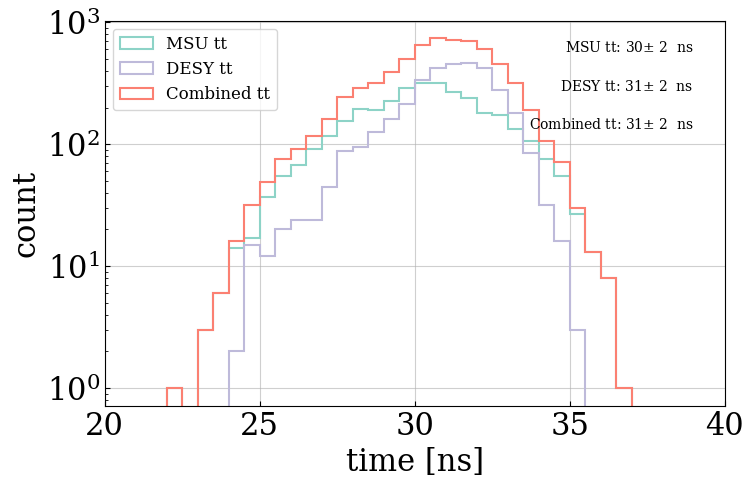

In [31]:
plot_transit_time_histogram2(transit_times_single_per_pmt_msu, transit_times_single_per_pmt_desy,plotFolder+"/transit_time_histogram_final_after_corrected_components",bins=np.linspace(20,40,41),xlim=[20,40],no_component=None)

In [ ]:
rse_msu = extract_rse_site(transit_times_single_per_pmt_file, mdom_tt_dir, site_str="_M", obj_key="b", filter_non_zero=False)
rse_desy = extract_rse_site(transit_times_single_per_pmt_file, mdom_tt_dir, site_str="_D", obj_key="b", filter_non_zero=False)
# plot_rse_histogram(rse_msu, rse_desy, plotFolder+"/rse_histogram_final",bins=np.linspace(0,20,41),xlim=[0,20])


In [56]:
def plot_rse_histogram2(rse_msu, rse_desy, plot_name,bins=200,xlim=[-10,4*10**5],no_component=None) -> None:
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    if no_component is None:
        ax.hist(rse_msu, bins=bins,histtype='step',color=colorsCustom[0],linewidth=1.5 ,label=r'MSU RSS', alpha=1)
        ax.hist(rse_desy, bins=bins,histtype='step',color=colorsCustom[1],linewidth=1.5 ,label=r'DESY RSS', alpha=1)
    ax.hist(rse_desy+rse_msu, bins=bins,histtype='step',color=colorsCustom[2],linewidth=1.5 ,label=r'Combined RSS', alpha=1)
    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.set_xlabel(r"Residual sum of squares", fontsize=22)
    ax.set_ylabel(r"count", fontsize=22)
    ax.set_yscale('log')
    # ax.set_xscale('log')
    if no_component is None:
        ax.text(0.95, 0.95, fr"MSU RSS: {np.mean(rse_msu):.0f}"+r"$\pm$" + fr" {np.std(rse_msu):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
        ax.text(0.95, 0.85, fr"DESY RSS: {np.mean(rse_desy):.0f}"+r"$\pm$" + fr" {np.std(rse_desy):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
    # ax.text(0.95, 0.75, fr"Combined RSS: {np.mean(rse_msu+rse_desy):.0f}"+r"$\pm$" + fr" {np.std(rse_msu+rse_desy):.0f}  ns", transform=ax.transAxes, ha='right', va='top')
    ax.grid(True,alpha=0.6)
    ax.set_xlim(xlim[0],xlim[1])
    ax.legend(fontsize=12,ncols=1)
    plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    # plt.close()
    plt.show()

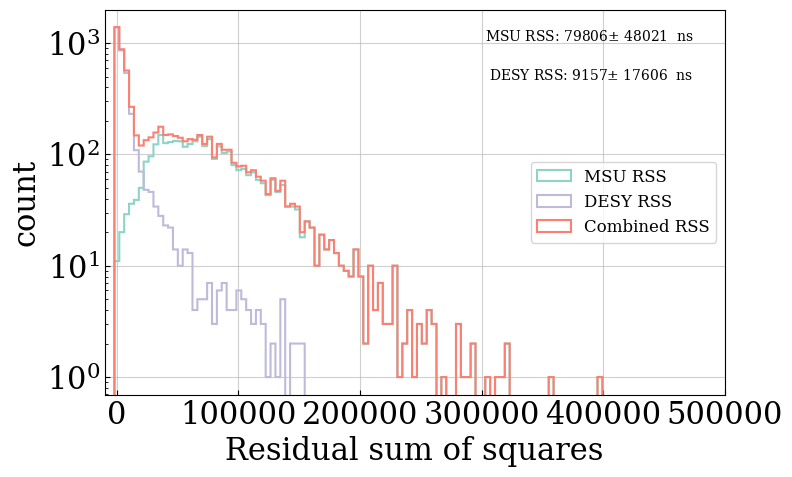

In [57]:
plot_rse_histogram2(rse_msu, rse_desy, plotFolder+"/rse_histogram_final_components",bins=np.linspace(-10**4,0.4*10**7,1000),xlim=[-10**4,0.05*10**7],no_component=None)

In [49]:
print(len(rse_msu))

3383


In [50]:
print(len(rse_desy))

3520


In [60]:
max(rse_msu)

np.float64(397015.8036050367)

In [61]:
#after refit

In [63]:
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"
# transit_times = extract_json(transit_time_file,obj_key="mu",filter_non_zero=False)
# transit_times_single_per_pmt = extract_json_unique_tt(transit_time_file,run_picks_json,refit_json,empty_meas_json,obj_key="mu",filter_non_zero=True)
transit_times_single_gauss_per_pmt_msu = extract_json_site(transit_times_single_gaussian_file,site_str="_M",obj_key="mu",filter_non_zero=False)
transit_times_single_gauss_per_pmt_desy = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="mu",filter_non_zero=False)
# print(transit_times_single_per_pmt)

In [64]:
tts_single_gauss_per_pmt_msu = extract_json_site(transit_times_single_gaussian_file,site_str="_M",obj_key="sigma",filter_non_zero=False)
tts_single_gauss_per_pmt_desy = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="sigma",filter_non_zero=False)

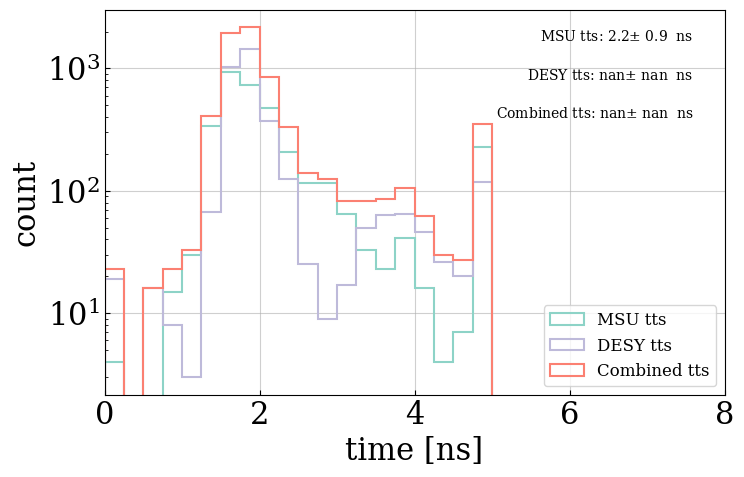

In [65]:
plot_transit_time_spread_histogram2(tts_single_gauss_per_pmt_msu, tts_single_gauss_per_pmt_desy,plotFolder+"/transit_time_spread_histogram_final",bins=np.linspace(0,8,33),xlim=[0,8],no_component=None)
